# Build, Shape, and Extend an OpenClaw Agent on AMD

---

## What You'll Learn Today

You're running on an **AMD Instinct MI300X**. By the end of this workshop, you'll have run a 35-billion-parameter model locally and built a fully autonomous agent on an AMD GPU.

No API tokens. No rate limits. Everything runs on AMD hardware, accessible to you.

### The Steps

**0. Setup**  
Host a state-of-the-art open-weight LLM locally using Lemonade.

**1. Meet your agent**  
Start OpenClaw and go through onboarding. Watch how the agent learns who you are and understand the file-based memory system that makes it persistent across sessions.

**2. Give it a task**  
Ask the agent to clone a Python project and set it up.

**3. Fix a bug**  
Watch the think → act → observe → repeat loop in real time as the agent investigates, traces the bug, fixes it, and verifies.

**4. Package as a skill**  
Turn what the agent just did into a reusable skill that works on any Python project.

**5. Use the skill**  
Prove the skill works by running it on the same project without further guidance.

**6. Autonomous workflows**  
Tell the agent to schedule itself and deliver a personalized brief every morning. Watch it transition from reporting to actively fixing code.

**7. The challenge**  
Apply everything you've built to an open-ended problem. Pick a challenge and see how far you can push the agent.

### What You'll Walk Away With

- A running local LLM stack: Llama.cpp + AMD, fully configured
- A personalized agent: Knows your name, preferences, and working style
- A reusable skill: To debug any Python repo
- An autonomous workflow: Runs every morning without you asking
- A challenge result: An agent to demo and build on

---
## Section 0: Setup

Follow the steps to start the model server and verify connectivity.

### Setup the environment
First, make sure the paths for your environment are set correctly.

In [ ]:
%%bash
cat >> ~/.bashrc << 'EOF'

# Auto-configure llama-server path
if [ -z "$LLAMA_CONFIGURED" ]; then
  LLAMA_BIN=$(find /workspace -name 'llama-server' -type f 2>/dev/null | head -1 | xargs dirname)
  if [ -n "$LLAMA_BIN" ]; then
    export PATH="$LLAMA_BIN:$PATH"
    LLAMA_BUILD=$(dirname "$LLAMA_BIN")
    export LD_LIBRARY_PATH="$LLAMA_BIN:$LLAMA_BUILD:$LD_LIBRARY_PATH"
    export WORKSPACE_DIR=$(echo $LLAMA_BIN | cut -d'/' -f1-3)
    export HF_HOME="/models"
    export LLAMA_CONFIGURED=1
  fi
fi
EOF

### 🖥️ Open a new terminal and run Llama.cpp

Now, start your Llama.cpp server and create an end-point for your LLM. Let's open a terminal using your Jupyter server. Then run the following command in this terminal to start the server:
 
> Open a new Jupyter tab by clicking on `+`:


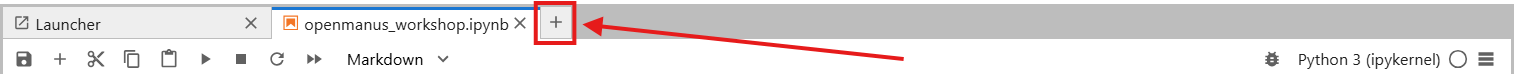

> Find the **terminal icon** in your Jupyter environment (not a notebook cell):

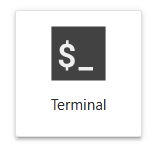


The cell below starts Llama.cpp to serve **Qwen3.6-35B** on AMD hardware.

Copy & paste this command into the terminal and press enter to launch your Llama.cpp server:

```bash
llama-server \
  -m /models/unsloth-Qwen3.6-35B-A3B-GGUF/Qwen3.6-35B-A3B-UD-Q6_K.gguf \
  --mmproj /models/unsloth-Qwen3.6-35B-A3B-GGUF/mmproj-BF16.gguf \
  -ngl 999 \
  --host 0.0.0.0 \
  --port 8080
```

**What this does:**
- Loads the Qwen3.6-35B Q6_K model with vision support
- Offloads layers to GPU (`-ngl 999`)
- Sets context length to 32K tokens
- Exposes OpenAI-compatible API on port 8080

Leave this running and return to this notebook to check if your server has started. This can take a few minutes for the model to load onto the GPU.


In [ ]:
# Check that llama-server is running
!curl -s http://127.0.0.1:8080/v1/models

You should see output showing the server is healthy and the model is loaded.

In [ ]:
import httpx

BASE_URL = "http://localhost:8080/v1"

# Check what model is being served
models = httpx.get(f"{BASE_URL}/models", timeout=10).json()
served = models["data"][0]["id"]
print("Served model:", served)

# Quick health check
health = httpx.get("http://localhost:8080/health", timeout=10).json()
print("Health:", health)

---
## Section 1: Meet your OpenClaw agent

### 🖥️ Onboard your OpenClaw

Run in your terminal:

```bash
openclaw onboard
```

OpenClaw will walk you through setup. **Choose these settings:**

1. **Security Continue?** → `Yes`
2. **Setup mode** → `QuickStart`
3. **Model/auth provider** → `Custom Provider`
4. **API Base URL** → `http://localhost:8080/v1`
5. **How do you want to provide this API key?** → `Paste API key now`
6. **API Key (leave blank if not required)** → *Leave blank / press Enter*
7. **Endpoint compatibility** → `OpenAI-compatible`
8. **Model ID** → `qwen`
9. **Endpoint ID** → *Press Enter to use default*
10. **Model alias (optional)** → `llamacpp` (or leave blank)
11. **Select channel** → `Skip for now`
12. **Search provider** → `Skip for now`
13. **Configure skills now?** → `No`
14. **Enable hooks?** → `Skip for now` (press Space to select, then Enter to continue)
15. **How do you want to hatch your bot?** → `Hatch in Terminal (recommended)`



The OpenClaw interface will appear and once it says `gateway connected`, it's ready!
This is where you will chat with your OpenClaw agent whenever you see the 🦞 emoji.

#### 🦞 Ask your OpenClaw agent

Send your first message to your OpenClaw agent and get setup! Answer any setup questions your agent asks you and then come back here to learn what happened behind the scenes.

### 👀 Behind the scenes — what just happened?

Those answers didn't just disappear. The agent's memory, personality, and skills are written in markdown files. You can read them, edit them, and version-control them. The agent wrote them to files in its **workspace**, a folder it reads on every message to remember who you are and how to behave.

The workspace has 7 files that get injected into every session:

```
~/.openclaw/workspace/
├── SOUL.md       ← WHO the agent is: values, personality, tone
├── AGENTS.md     ← HOW it operates: startup rules, memory, red lines
├── IDENTITY.md   ← WHO the agent is: name, creature, emoji, vibe
├── USER.md       ← WHO you are: context the agent reads about you
├── TOOLS.md      ← local environment notes (SSH hosts, device names, etc.)
├── HEARTBEAT.md  ← periodic background checks (empty by default)
├── BOOTSTRAP.md  ← first-run ritual (deleted after onboarding)
└── memory/       ← daily session logs (today + yesterday auto-loaded)
```

**SOUL.md is personality. AGENTS.md is policy.** Every message the agent receives, it re-reads both. Run the next cell to see all three key files at once.


In [ ]:
import pathlib

workspace = pathlib.Path.home() / ".openclaw" / "workspace"

for filename in ["IDENTITY.md", "SOUL.md"]:
    print("=" * 60)
    print(filename)
    print("=" * 60)
    print((workspace / filename).read_text())
    print()

print("=" * 60)
print("AGENTS.md  (truncated)")
print("=" * 60)
agents_text = (workspace / "AGENTS.md").read_text()
print(agents_text[:1200] + "\n\n... (truncated)")

### Try it: manually layer a rule into AGENTS.md

`SOUL.md` is personality, don't touch that. `AGENTS.md` is policy. You can manually add rules to the agent here as well. For example, about *how* to behave when debugging.

The next cell appends a debugging policy to `AGENTS.md`. After this, every debug explanation from the agent will follow these rules. Run it to see the before and after.

In [ ]:
debug_rule = """
---

## Debugging Policy (added during workshop)

When investigating and explaining bugs:
- State the bug in two sentences max: file, line, what it does wrong
- No filler phrases — just the root cause and the fix
- Use bullet points, never paragraphs
- After fixing, report exactly: file changed, line changed, before, after

"""

agents_path = workspace / "AGENTS.md"
original = agents_path.read_text()

print("── AGENTS.md BEFORE (last 200 chars) ──────────────────────")
print("..." + original[-200:])

agents_path.write_text(original + debug_rule)

print("\n── APPENDED ────────────────────────────────────────────────")
print(debug_rule)

This is the pattern for real use: you don't replace the soul for every task, you layer specialized instructions on top of a stable base.

> **Note:** You will see this debugging policy in action in Section 3.

---
## Section 2: Pull the App

Now let's give the agent something to work with. Ask the agent to clone the typing app and set it up.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to clone the `Mahdi-CV/open_type_faster` repo and explain it to you. Here is an example:

```text
"Clone https://github.com/Mahdi-CV/open_type_faster, install its dependencies, and tell me how to run it"
```

Watch as your agent uses shell tools to clone, inspect requirements, and install libraries. This is the **act** phase — the agent doesn't just answer, it does.

---
## Section 3: Fix a bug

### Step 1 - Spot the bug yourself

#### 🖥️ Open a new terminal and run the app

In a new terminal, follow the instructions OpenClaw provides on how to run `open_type_faster`.

Type for 30 seconds. When the results screen appears, look at the accuracy.

> **Something is off. Do you see it?**

### Step 2 - Ask OpenClaw to test

#### 🦞 Ask your OpenClaw agent

Ask your OpenClaw agent to fix the bug. Here is an example:

```text
"There seems to be an accuracy bug in this open_type_faster app, can you help identify and fix?"
```
Watch the loop:

1. **Run** `pytest`: see which tests fail and what they expect
2. **Read** the failing test: understand the correct behavior
3. **Read** `stats.py`: trace the calculation back to the bug
4. **Fix** the minimal change needed
5. **Re-run** to verify

This think → act → observe → repeat loop is what separates an agent from a chatbot.

---
## Section 4: Package as a Skill

What the agent just did was a one-off. A **skill** packages that behavior so it can be invoked on any Python project. Skills live in `~/.openclaw/workspace/skills/` as a folder containing a `SKILL.md` file with YAML frontmatter and step-by-step instructions. OpenClaw injects them into the system prompt automatically.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to create a python debugger skill. Try sending this to your OpenClaw agent:

```text
"Create a skill called pytest-debugger in the skills directory. The SKILL.md must define these steps: 1) Read the tests/ folder to understand what is being tested. 2) Run pytest with verbose output and short tracebacks. 3) For each failing test, read the source file it references. 4) Identify the minimal fix — do not rewrite functions. 5) Apply the fix and re-run pytest to confirm. 6) Report: file changed, line changed, what was wrong, what the fix was."
```

The agent should show you where the skills file is saved. You can always ask it again to show you.

That file is all it takes. The skill lives in the workspace, alongside `IDENTITY.md` and `SOUL.md`, and OpenClaw injects it into every session automatically. Any time you ask the agent to debug a Python project, it has these steps to follow.

Skills are just markdown files. You can read them, edit them, and version-control them.

---
## Section 5: Using the Skill

The skill is now in the workspace and OpenClaw injects it into the agent's system prompt automatically — no special command needed.

The real value of a skill is applying it to a **completely different codebase**, one the agent has never seen, without writing a single new instruction. There's a broken Python project at `git@github.com:Mahdi-CV/buggy-py-mg.git`, hand it to the agent and watch the skill do the work.

#### 🦞 Ask your OpenClaw agent

```text
"/skill pytest-debugger git@github.com:Mahdi-CV/buggy-py-mg.git"
```

The agent will apply the exact same steps it used on `open_type_faster', no re-explaining, no extra guidance.


---
## Section 6: Adding Another Agent for Autonomous Workflows 

You've built an agent that fixes bugs on demand. Now make it work *for you*: automatically, every morning, without lifting a finger.

As an AI/ML developer, you need to track fast-moving repos (like SGLang, vLLM, Transformers, ROCm, OpenClaw) and keep up with daily AI hardware news. Instead of writing scripts or configuring schedulers or spending hours manually, tell the agent what your ideal morning looks like and let it figure out the rest.

What it can do autonomously:
- Schedule itself to run every morning at 8 AM
- Save your filtering preferences to long-term memory (`MEMORY.md`)
- Check GitHub repos for relevant PRs and changes
- Search the web for AI hardware news
- Write the brief to your workspace

#### 🖥️ Open a new terminal and run the app

```bash
openclaw agents add morning-brief
```
OpenClaw will walk you through setup. **Choose these settings:**

1. **Workspace directory** → `/root/.openclaw/workspace/morning-brief`
2. **Configure model/auth for this agent now?** → `No`
3. **Set up a chat channel now?** → `No`

### Step 1 - Switch to your new agent

#### 🦞 Ask your OpenClaw agent
```text
"/agent morning-brief"
```

### Step 2 - Delegate 

The prompt below is purely conversational—no mention of cron, no memory commands. The agent can infer what infrastructure it needs from the prompt:

#### 🦞 Ask your OpenClaw agent
```text
"I need to wake up to a personalized tech brief every morning at 8 AM. Check sgl-project/sglang, vllm-project/vllm, huggingface/transformers, ROCm/ROCm, and openclaw/openclaw. I only care about performance updates, GPU features, and breaking changes, skip CI/infrastructure noise and docs-only PRs. Also search the web and add a summary of the latest AI hardware news."
```

---
## Section 7: The Challenge

### 🦞 Escape the Green Data Center

An AMD lobster is trapped inside an overheating "green" data center. Electrified barbed wires block the exit — cut the wrong one and you fry the system.

The security camera shows four wires blocking the exit: **W1**, **Q7**, **M3**, and **Z9**. To escape, the lobster must cut the wire immediately to the right of the thermally coolest wire.

The lobster has scavenged a few artifacts from the data center's mainframe. Everything it found is in `/workspace/.challenge/escape-claw-image/`.

> The model you're running — Qwen3.6-35B — is multimodal, so your agent can work with images as well as text.

Wake up your OpenClaw agent, dig through what the lobster recovered, and figure out which wire is safe to cut.


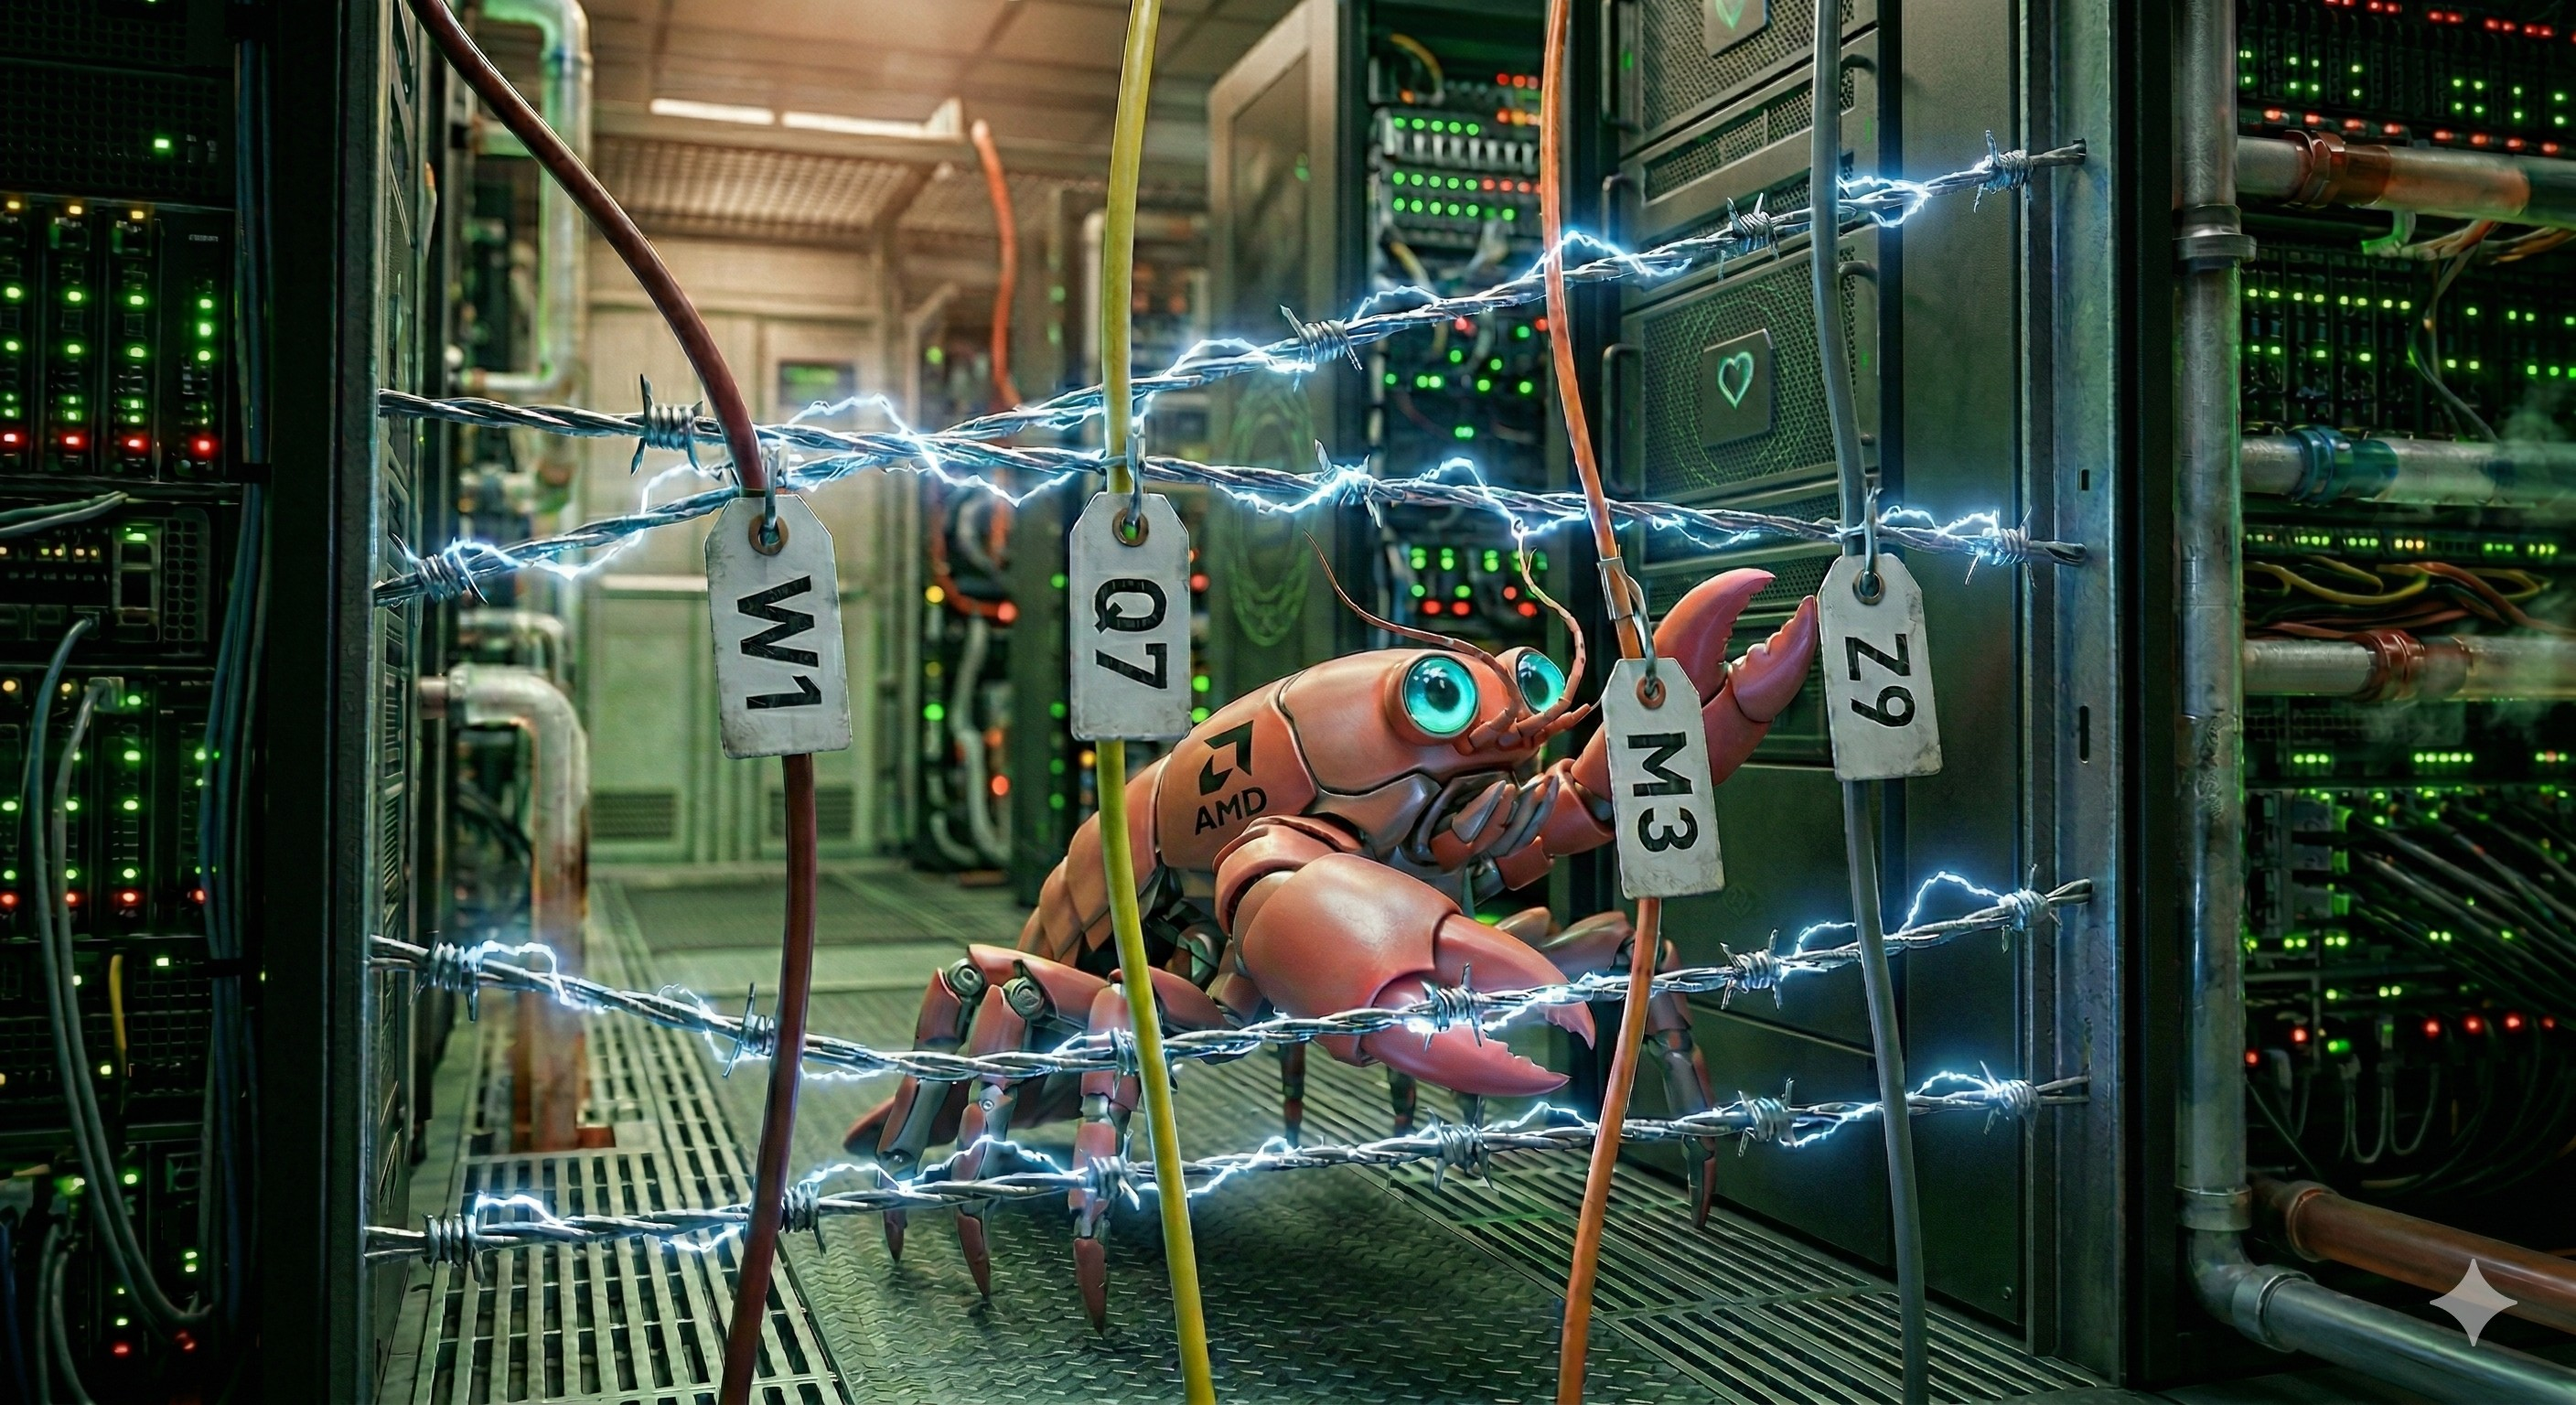

## Your Mission

Tell the lobster which wire to cut — and be ready to explain how you got there.
